# Feature Engineering - Data Challenge QRT
## Préparation des Données pour la Modélisation

---

## 1. Imports et Chargement des Données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
from matplotlib.lines import Line2D
warnings.filterwarnings('ignore')
# Sklearn
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import cross_val_score, KFold
from sklearn.impute import SimpleImputer
from scipy import stats

# Configuration
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_palette('husl')
np.random.seed(42)

In [2]:
# Chargement des données
BASE_DIR = Path('..')
clinical_train = pd.read_csv(BASE_DIR / 'X_train' / 'clinical_train.csv')
molecular_train = pd.read_csv(BASE_DIR / 'X_train' / 'molecular_train.csv')
y_train = pd.read_csv(BASE_DIR / 'target_train.csv')
clinical_test = pd.read_csv(BASE_DIR / 'X_test_xzVefmA' / 'X_test' / 'clinical_test.csv')
molecular_test = pd.read_csv(BASE_DIR / 'X_test_xzVefmA' / 'X_test' / 'molecular_test.csv')
print("Données chargées:")
print(f"   Clinical Train : {clinical_train.shape}")
print(f"   Molecular Train: {molecular_train.shape}")
print(f"   Y Train        : {y_train.shape}")

Données chargées:
   Clinical Train : (3323, 9)
   Molecular Train: (10935, 11)
   Y Train        : (3323, 3)


---
## 2. Création des Features par Patient

### 2.1 Features Moléculaires (Mutations)

In [3]:
print(" CRÉATION DES FEATURES MOLÉCULAIRES")
# Nombre total de mutations par patient
mutations_count = molecular_train.groupby('ID').size().reset_index(name='N_MUTATIONS')
# Nombre de gènes distincts mutés par patient
genes_count = molecular_train.groupby('ID')['GENE'].nunique().reset_index(name='N_GENES_MUTES')
# VAF moyen et max par patient
vaf_stats = molecular_train.groupby('ID')['VAF'].agg(['mean', 'max', 'std']).reset_index()
vaf_stats.columns = ['ID', 'VAF_MEAN', 'VAF_MAX', 'VAF_STD']
# Nombre de mutations par type d'effet
effect_pivot = molecular_train.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
effect_pivot.columns = ['EFFECT_' + str(col).upper().replace(' ', '_') for col in effect_pivot.columns]
effect_pivot = effect_pivot.reset_index()

# Sélection automatique des gènes importants basée sur les DONNÉES
print("\n Sélection automatique des gènes importants...")

# Créer la matrice de présence pour tous les gènes
gene_presence = molecular_train.groupby(['ID', 'GENE']).size().unstack(fill_value=0)
gene_presence = (gene_presence > 0).astype(int)

#-----
# Joindre avec y_train pour calculer l'impact sur la survie
gene_survival_analysis = gene_presence.merge(y_train, left_index=True, right_on='ID')

# Top gènes les plus FRÉQUENTS
top_frequent_genes = molecular_train['GENE'].value_counts().head(15).index.tolist()
print("\n Top 15 gènes les plus fréquents:")
for i, g in enumerate(top_frequent_genes[:10], 1):
    freq = molecular_train['GENE'].value_counts()[g]
    pct = freq / molecular_train['ID'].nunique() * 100
    print(f"   {i:2d}. {g:12s}: {freq:4d} mutations ({pct:.1f}% des patients)")

# Top gènes les plus CORRÉLÉS à la survie 
gene_impact_scores = []
for gene in gene_presence.columns:
    if gene in gene_survival_analysis.columns:
        with_mut = gene_survival_analysis[gene_survival_analysis[gene] == 1]
        without_mut = gene_survival_analysis[gene_survival_analysis[gene] == 0]
        if len(with_mut) >= 20:  # Au moins 20 patients avec la mutation on sélectionne le gène.
            mort_diff = abs(with_mut['OS_STATUS'].mean() - without_mut['OS_STATUS'].mean())
            surv_diff = abs(with_mut['OS_YEARS'].mean() - without_mut['OS_YEARS'].mean())
            impact_score = mort_diff * 0.6 + surv_diff * 0.1  # Pondéré vers la mortalité
            gene_impact_scores.append({
                'gene': gene,
                'n_patients': len(with_mut),
                'mort_diff': mort_diff,
                'surv_diff': surv_diff,
                'impact_score': impact_score
            })

gene_impact_df = pd.DataFrame(gene_impact_scores).sort_values('impact_score', ascending=False)
top_impact_genes = gene_impact_df.head(15)['gene'].tolist()

print("\n trouver les gènes par impact sur la survie:")
for _, row in gene_impact_df.head(10).iterrows():
    print(f"   {row['gene']:12s}: deltatalité={row['mort_diff']*100:+.1f}%, deltasurvie={row['surv_diff']:+.2f} ans ({row['n_patients']} patients)")

# Combiner les deux méthodes: union des gènes fréquents ET impactants
important_genes = list(set(top_frequent_genes[:10]) | set(top_impact_genes[:10]))
print(f"\n Gènes sélectionnés (union fréquence + impact): {len(important_genes)}")
print(f"   {important_genes}")

# Créer les features de présence
existing_genes = [g for g in important_genes if g in gene_presence.columns]
gene_features = gene_presence[existing_genes].reset_index()
gene_features.columns = ['ID'] + ['HAS_' + g for g in existing_genes]

print("\n FEATURES MOLÉCULAIRES CRÉÉES :")
print(" - Quantité de mutations       : N_MUTATIONS, N_GENES_MUTES")
print(" - Profil VAF                  : VAF_MEAN, VAF_MAX, VAF_STD")
print(f" - Types d'effet               : EFFECT_* (\"EFFECT_...\" pour {len(effect_pivot.columns)-1} types)")
print(f" - Présence de gènes importants: HAS_<GENE> pour {len(existing_genes)} gènes sélectionnés")

 CRÉATION DES FEATURES MOLÉCULAIRES

 Sélection automatique des gènes importants...

 Top 15 gènes les plus fréquents:
    1. TET2        : 1663 mutations (55.0% des patients)
    2. ASXL1       :  951 mutations (31.4% des patients)
    3. SF3B1       :  775 mutations (25.6% des patients)
    4. DNMT3A      :  604 mutations (20.0% des patients)
    5. RUNX1       :  578 mutations (19.1% des patients)
    6. SRSF2       :  577 mutations (19.1% des patients)
    7. TP53        :  487 mutations (16.1% des patients)
    8. STAG2       :  376 mutations (12.4% des patients)
    9. U2AF1       :  288 mutations (9.5% des patients)
   10. EZH2        :  252 mutations (8.3% des patients)

 trouver les gènes par impact sur la survie:
   FLT3        : deltatalité=+29.6%, deltasurvie=+0.96 ans (50 patients)
   TP53        : deltatalité=+24.2%, deltasurvie=+1.08 ans (379 patients)
   CEBPA       : deltatalité=+19.6%, deltasurvie=+1.03 ans (74 patients)
   NFE2        : deltatalité=+0.8%, deltasurvie

In [4]:
# Fusionner toutes les features moléculaires
molecular_features = mutations_count.merge(genes_count, on='ID', how='outer')
molecular_features = molecular_features.merge(vaf_stats, on='ID', how='outer')
molecular_features = molecular_features.merge(effect_pivot, on='ID', how='outer')
molecular_features = molecular_features.merge(gene_features, on='ID', how='outer')
print(f"\n Features moléculaires: {molecular_features.shape}")
molecular_features.head()


 Features moléculaires: (3026, 40)


,ID,N_MUTATIONS,N_GENES_MUTES,VAF_MEAN,VAF_MAX,VAF_STD,EFFECT_2KB_UPSTREAM_VARIANT,EFFECT_3_PRIME_UTR_VARIANT,EFFECT_ITD,EFFECT_PTD,...,HAS_NRAS,HAS_STAG2,HAS_ASXL1,HAS_TP53,HAS_FLT3,HAS_NFE2,HAS_TET2,HAS_GATA2,HAS_SF3B1,HAS_SMC1A
0,P100000,6,6,0.3013,0.7730,0.290267,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
1,P100001,2,2,0.2595,0.4180,0.224153,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,P100002,2,2,0.3970,0.5970,0.282843,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
3,P100004,1,1,0.4691,0.4691,NaN,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
4,P100006,5,5,0.1693,0.3720,0.148994,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


### 2.2 Features Cliniques + Valeurs Manquantes

In [ ]:
print("="*60)
print(" CRÉATION DES FEATURES CLINIQUES")
print("="*60)
numeric_cols = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
clinical_train['N_MISSING'] = clinical_train[numeric_cols].isnull().sum(axis=1)
for col in numeric_cols:
    clinical_train[f'{col}_MISSING'] = clinical_train[col].isnull().astype(int)
def categorize_cytogenetics(cyto):
    if pd.isna(cyto):
        return 'Unknown'
    cyto = str(cyto).lower()
    if cyto in ['normal', '46,xy', '46,xx', '46,xy[20]', '46,xx[20]']:
        return 'Normal'
    if 'complex' in cyto:
        return 'Complex'
    if '-7' in cyto or 'del(7)' in cyto:
        return 'Monosomy_7'
    if '-5' in cyto or 'del(5)' in cyto:
        return 'Del_5q'
    if '+8' in cyto:
        return 'Trisomy_8'
    if 'del(20)' in cyto:
        return 'Del_20q'
    return 'Other_abnormality'

clinical_train['CYTO_CATEGORY'] = clinical_train['CYTOGENETICS'].apply(categorize_cytogenetics)
cyto_dummies = pd.get_dummies(clinical_train['CYTO_CATEGORY'], prefix='CYTO') # on code en one-hot les categories de chromosomes
clinical_train = pd.concat([clinical_train, cyto_dummies], axis=1)
clinical_train['RATIO_WBC_PLT'] = clinical_train['WBC'] / (clinical_train['PLT'] + 1) #entier
clinical_train['RATIO_ANC_WBC'] = clinical_train['ANC'] / (clinical_train['WBC'] + 0.1)
clinical_train['RATIO_MONO_WBC'] = clinical_train['MONOCYTES'] / (clinical_train['WBC'] + 0.1)

print("\n Features cliniques créées:")
print("    N_MISSING            : nombre de valeurs manquantes")
print("   *_MISSING            : indicateurs de valeurs manquantes")
print("   CYTO_*               : catégories cytogénétiques (one-hot)")
print("   RATIO_*              : ratios biologiques")

print(f"\n Shape clinical enrichi: {clinical_train.shape}")

 CRÉATION DES FEATURES CLINIQUES

 Features cliniques créées:
    N_MISSING            : nombre de valeurs manquantes
   *_MISSING            : indicateurs de valeurs manquantes
   CYTO_*               : catégories cytogénétiques (one-hot)
   RATIO_*              : ratios biologiques

 Shape clinical enrichi: (3323, 28)


### 2.3 Fusion Complète des deux features

In [6]:
print("="*60)
print(" FUSION DES DONNÉES")
df_full = clinical_train.merge(molecular_features, on='ID', how='left')
mutation_cols = [c for c in df_full.columns if c.startswith(('N_', 'VAF_', 'EFFECT_', 'HAS_'))]
for col in mutation_cols:
    if col.startswith(('HAS_', 'EFFECT_')) or col in ['N_MUTATIONS', 'N_GENES_MUTES']:
        df_full[col] = df_full[col].fillna(0)
df_full = df_full.merge(y_train, on='ID')

print(f"\n Dataset final: {df_full.shape[0]} patients × {df_full.shape[1]} variables")
print(f"\n Colonnes ({len(df_full.columns)}):")
print(df_full.columns.tolist())
df_full.head()

 FUSION DES DONNÉES

 Dataset final: 3323 patients × 69 variables

 Colonnes (69):
['ID', 'CENTER', 'BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'CYTOGENETICS', 'N_MISSING', 'BM_BLAST_MISSING', 'WBC_MISSING', 'ANC_MISSING', 'MONOCYTES_MISSING', 'HB_MISSING', 'PLT_MISSING', 'CYTO_CATEGORY', 'CYTO_Complex', 'CYTO_Del_20q', 'CYTO_Del_5q', 'CYTO_Monosomy_7', 'CYTO_Normal', 'CYTO_Other_abnormality', 'CYTO_Trisomy_8', 'CYTO_Unknown', 'RATIO_WBC_PLT', 'RATIO_ANC_WBC', 'RATIO_MONO_WBC', 'N_MUTATIONS', 'N_GENES_MUTES', 'VAF_MEAN', 'VAF_MAX', 'VAF_STD', 'EFFECT_2KB_UPSTREAM_VARIANT', 'EFFECT_3_PRIME_UTR_VARIANT', 'EFFECT_ITD', 'EFFECT_PTD', 'EFFECT_COMPLEX_CHANGE_IN_TRANSCRIPT', 'EFFECT_FRAMESHIFT_VARIANT', 'EFFECT_INFRAME_CODON_GAIN', 'EFFECT_INFRAME_CODON_LOSS', 'EFFECT_INFRAME_VARIANT', 'EFFECT_INITIATOR_CODON_CHANGE', 'EFFECT_NON_SYNONYMOUS_CODON', 'EFFECT_SPLICE_SITE_VARIANT', 'EFFECT_STOP_GAINED', 'EFFECT_STOP_LOST', 'EFFECT_STOP_RETAINED_VARIANT', 'EFFECT_SYNONYMOUS_CODON', 'HAS_CE

,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS,N_MISSING,...,HAS_ASXL1,HAS_TP53,HAS_FLT3,HAS_NFE2,HAS_TET2,HAS_GATA2,HAS_SF3B1,HAS_SMC1A,OS_YEARS,OS_STATUS
0,P132697,MSK,14.0,2.8,0.2,0.7,7.6,119.0,"46,xy,del(20)(q12)[2]/46,xy[18]",0,...,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.115068,1.0
1,P132698,MSK,1.0,7.4,2.4,0.1,11.6,42.0,"46,xx",0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.928767,0.0
2,P116889,MSK,15.0,3.7,2.1,0.1,14.2,81.0,"46,xy,t(3;3)(q25;q27)[8]/46,xy[12]",0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,2.043836,0.0
3,P132699,MSK,1.0,3.9,1.9,0.1,8.9,77.0,"46,xy,del(3)(q26q27)[15]/46,xy[5]",0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.476712,1.0
4,P132700,MSK,6.0,128.0,9.7,0.9,11.1,195.0,"46,xx,t(3;9)(p13;q22)[10]/46,xx[10]",0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.145205,0.0


---
## 3. Visualisation ACP et t-SNE



In [7]:
print("="*60)
print(" PRÉPARATION POUR ACP/t-SNE")
exclude_cols = ['ID', 'CYTOGENETICS', 'CENTER', 'CYTO_CATEGORY', 'OS_YEARS', 'OS_STATUS']
feature_cols = [c for c in df_full.columns if c not in exclude_cols and df_full[c].dtype in ['int64', 'float64']]
print(f"\n Features sélectionnées ({len(feature_cols)}):")
print(feature_cols)
X = df_full[feature_cols].copy()
y_years = df_full['OS_YEARS'].values
y_status = df_full['OS_STATUS'].values


 PRÉPARATION POUR ACP/t-SNE

 Features sélectionnées (55):
['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT', 'N_MISSING', 'BM_BLAST_MISSING', 'WBC_MISSING', 'ANC_MISSING', 'MONOCYTES_MISSING', 'HB_MISSING', 'PLT_MISSING', 'RATIO_WBC_PLT', 'RATIO_ANC_WBC', 'RATIO_MONO_WBC', 'N_MUTATIONS', 'N_GENES_MUTES', 'VAF_MEAN', 'VAF_MAX', 'VAF_STD', 'EFFECT_2KB_UPSTREAM_VARIANT', 'EFFECT_3_PRIME_UTR_VARIANT', 'EFFECT_ITD', 'EFFECT_PTD', 'EFFECT_COMPLEX_CHANGE_IN_TRANSCRIPT', 'EFFECT_FRAMESHIFT_VARIANT', 'EFFECT_INFRAME_CODON_GAIN', 'EFFECT_INFRAME_CODON_LOSS', 'EFFECT_INFRAME_VARIANT', 'EFFECT_INITIATOR_CODON_CHANGE', 'EFFECT_NON_SYNONYMOUS_CODON', 'EFFECT_SPLICE_SITE_VARIANT', 'EFFECT_STOP_GAINED', 'EFFECT_STOP_LOST', 'EFFECT_STOP_RETAINED_VARIANT', 'EFFECT_SYNONYMOUS_CODON', 'HAS_CEBPA', 'HAS_RUNX1', 'HAS_U2AF1', 'HAS_MLL', 'HAS_DNMT3A', 'HAS_ETV6', 'HAS_EZH2', 'HAS_SRSF2', 'HAS_NRAS', 'HAS_STAG2', 'HAS_ASXL1', 'HAS_TP53', 'HAS_FLT3', 'HAS_NFE2', 'HAS_TET2', 'HAS_GATA2', 'HAS_SF3B1', 'HAS_SMC

In [8]:
#gestion des valeurs manquantes et scaling
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)#noramlisasation classique
print(f"\n X préparé: {X_scaled.shape}")


 X préparé: (3323, 55)



 Analyse en Composantes Principales (ACP)
--------------------------------------------------

 Variance expliquée:
   PC1: 9.9%
   PC2: 9.1%
   PC3: 5.1%
   PC4: 4.1%
   PC5: 3.9%
   Total (5 composantes): 32.1%


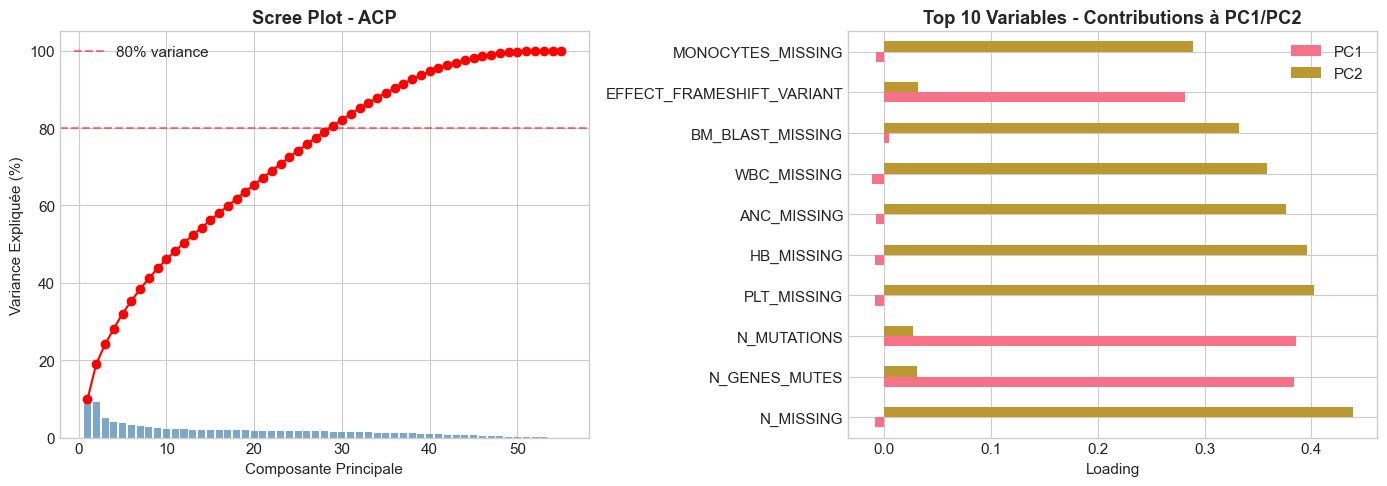

In [13]:
# ACP
print("\n Analyse en Composantes Principales (ACP)")
print("-"*50)
pca = PCA(n_components=X_scaled.shape[1])
X_pca = pca.fit_transform(X_scaled)
print("\n Variance expliquée:")
for i, var in enumerate(pca.explained_variance_ratio_[:5]):
    print(f"   PC{i+1}: {var*100:.1f}%")
print(f"   Total (5 composantes): {sum(pca.explained_variance_ratio_[:5])*100:.1f}%")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, X_scaled.shape[1] + 1), pca.explained_variance_ratio_ * 100, alpha=0.7, color='steelblue')
axes[0].plot(range(1, X_scaled.shape[1] + 1), np.cumsum(pca.explained_variance_ratio_) * 100, 'ro-')
axes[0].axhline(y=80, color='red', linestyle='--', alpha=0.5, label='80% variance')
axes[0].set_xlabel('Composante Principale')
axes[0].set_ylabel('Variance Expliquée (%)')
axes[0].set_title('Scree Plot - ACP', fontweight='bold')
axes[0].legend()

loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=feature_cols)
top_loadings = loadings.abs().sum(axis=1).sort_values(ascending=False).head(10)
loadings_top = loadings.loc[top_loadings.index]
loadings_top.plot(kind='barh', ax=axes[1])
axes[1].set_xlabel('Loading')
axes[1].set_title('Top 10 Variables - Contributions à PC1/PC2', fontweight='bold')
plt.tight_layout()
plt.show()

**On remarque que l'interie expliquée reste toujours faible à 10 composantes princiaples , l'idée de pouvoir representées ces données avec l'ACP sera compelètement érronée.**

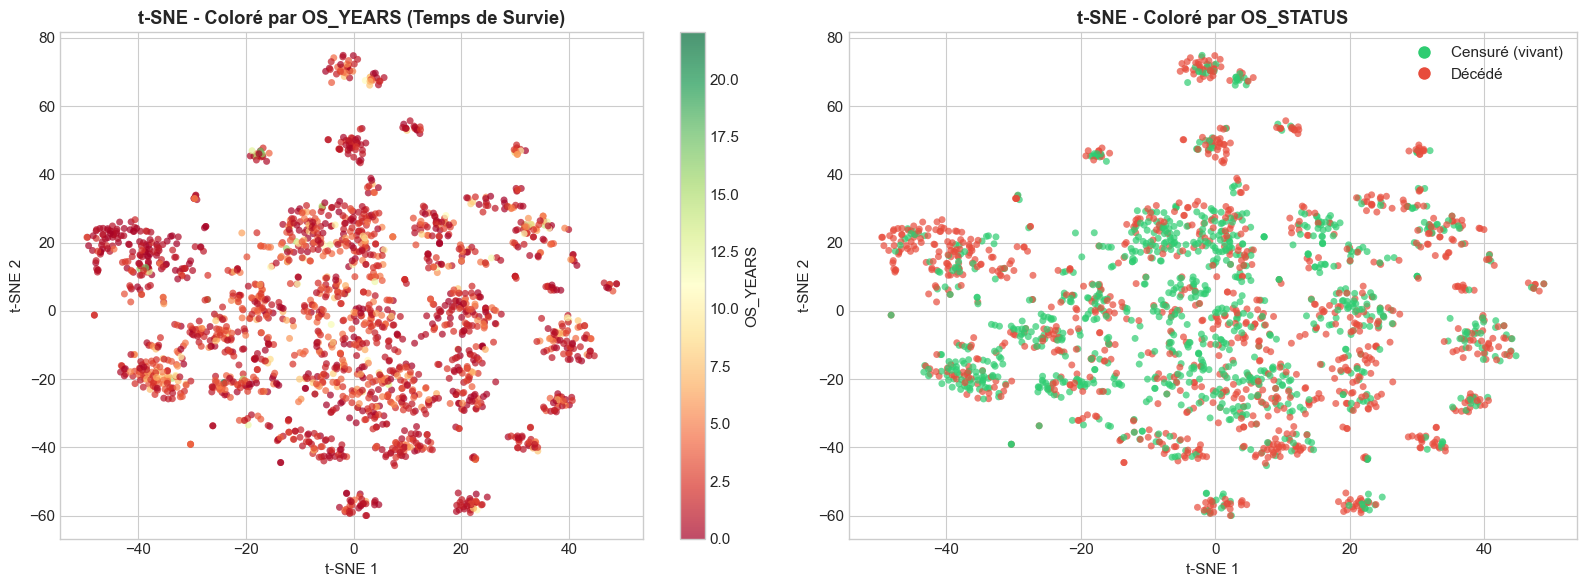

In [14]:
# Visualisation t-SNE
n_samples = min(2000, len(X_scaled))
idx = np.random.choice(len(X_scaled), n_samples, replace=False)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42, init='pca')
X_tsne = tsne.fit_transform(X_scaled[idx])
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=10, label='Censuré (vivant)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=10, label='Décédé')
]

scatter1 = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_years[idx], cmap='RdYlGn', alpha=0.7, s=25, edgecolors='none')
axes[0].set_xlabel('t-SNE 1')
axes[0].set_ylabel('t-SNE 2')
axes[0].set_title('t-SNE - Coloré par OS_YEARS (Temps de Survie)', fontweight='bold')
plt.colorbar(scatter1, ax=axes[0], label='OS_YEARS')

colors_tsne = ['#2ecc71' if y_status[i] == 0 else '#e74c3c' for i in idx]
axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=colors_tsne, alpha=0.7, s=25, edgecolors='none')
axes[1].set_xlabel('t-SNE 1')
axes[1].set_ylabel('t-SNE 2')
axes[1].set_title('t-SNE - Coloré par OS_STATUS', fontweight='bold')
axes[1].legend(handles=legend_elements, loc='upper right')
plt.tight_layout()
plt.show()

**On observe que les données ne forment pas de groupes linéaires selon les variables cibles. Il demeure incertain quel type d’espace serait le plus adapté pour optimiser le coût computationnel des méthodes de réduction de dimension. On peut toutefois conclure que les données sont dispersées dans l’espace des features, sans regroupement évident de variables.**

---
## 4. Test de Transformations avec Validation Croisée

Nous allons tester 3 transformations différentes et utiliser des tests statistiques pour choisir la meilleure.

In [15]:
print("="*60)
print(" TEST DES TRANSFORMATIONS")
# Définir les 3 transformations à tester
transformations = {
    'Standard (Z-score)': StandardScaler(),
    'MinMax [0,1]': MinMaxScaler(),
    'Robust (IQR)': RobustScaler()  # Résistant aux outliers
}
results = {}
# Fonction pour détecter les outliers avec la méthode IQR
def detect_outliers_iqr(X):
    """Détecte les outliers avec la méthode IQR: valeur > Q3 + 1.5*IQR ou < Q1 - 1.5*IQR"""
    Q1 = np.percentile(X, 25, axis=0)
    Q3 = np.percentile(X, 75, axis=0)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers_mask = (X < lower_bound) | (X > upper_bound)
    return outliers_mask
for name, scaler in transformations.items():
    print(f"\nTransformation: {name}")
    print("-"*40)
    # Appliquer la transformation
    X_transformed = scaler.fit_transform(X_imputed)  
    # Compter les outliers avec la méthode IQR (Q3 + 1.5*IQR ou Q1 - 1.5*IQR)
    outliers_mask = detect_outliers_iqr(X_transformed)
    n_outliers = outliers_mask.sum()
    pct_outliers = n_outliers / X_transformed.size * 10
    print(f"   Outliers: {n_outliers} ({pct_outliers:.2f}%)")
    # Distribution par variable
    outliers_per_var = outliers_mask.sum(axis=0)
    top_outlier_vars = np.argsort(outliers_per_var)[-3:][::-1]
    print("   Variables avec le plus d'outliers:")
    for idx_var in top_outlier_vars:
        print(f"      - {feature_cols[idx_var]}: {outliers_per_var[idx_var]}")
    
    results[name] = {
        'n_outliers': n_outliers,
        'pct_outliers': pct_outliers,
        'X_transformed': X_transformed
    }

 TEST DES TRANSFORMATIONS

Transformation: Standard (Z-score)
----------------------------------------
   Outliers: 10479 (0.57%)
   Variables avec le plus d'outliers:
      - HAS_SF3B1: 739
      - N_MISSING: 649
      - MONOCYTES_MISSING: 601

Transformation: MinMax [0,1]
----------------------------------------
   Outliers: 10478 (0.57%)
   Variables avec le plus d'outliers:
      - HAS_SF3B1: 739
      - N_MISSING: 649
      - MONOCYTES_MISSING: 601

Transformation: Robust (IQR)
----------------------------------------
   Outliers: 10478 (0.57%)
   Variables avec le plus d'outliers:
      - HAS_SF3B1: 739
      - N_MISSING: 649
      - MONOCYTES_MISSING: 601


**On peut ne pas traiter ces données car il n'ya pas de différence majeur en terme d'outlier sur ces trois méthodes**

In [21]:
print(" TRANSFORMATION STANDARD ET SAUVEGARDE")
# Transformation Standard (moyenne=0, écart-type=1)
scaler_standard = StandardScaler()
X_train_transformed = scaler_standard.fit_transform(X_imputed)
# Créer un DataFrame avec les données transformées
Train_transformed_data = pd.DataFrame(X_train_transformed, columns=feature_cols)
# Ajouter l'ID et les variables cibles
Train_transformed_data.insert(0, 'ID', df_full['ID'].values)
Train_transformed_data['OS_YEARS'] = df_full['OS_YEARS'].values
Train_transformed_data['OS_STATUS'] = df_full['OS_STATUS'].values

print("\nDonnées transformées (Standard Z-score):")
print(f"   Train Shape: {Train_transformed_data.shape}")
# Sauvegarder
output_dir = BASE_DIR / 'data'/'processed'
output_dir.mkdir(parents=True, exist_ok=True)
Train_transformed_data.to_csv(output_dir/'Train_transformed_data.csv', index=False)
print(f"\nSauvegardé: {output_dir/'Train_transformed_data.csv'}")
Train_transformed_data.head()

 TRANSFORMATION STANDARD ET SAUVEGARDE

Données transformées (Standard Z-score):
   Train Shape: (3323, 58)

Sauvegardé: ..\data\processed\Train_transformed_data.csv


,ID,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,N_MISSING,BM_BLAST_MISSING,WBC_MISSING,...,HAS_ASXL1,HAS_TP53,HAS_FLT3,HAS_NFE2,HAS_TET2,HAS_GATA2,HAS_SF3B1,HAS_SMC1A,OS_YEARS,OS_STATUS
0,P132697,1.081007,-0.359335,-0.587623,-0.061858,-1.139539,-0.315948,-0.369343,-0.184158,-0.298582,...,1.649595,-0.358799,8.090735,-0.095448,1.488907,-0.12731,-0.534781,-0.093829,1.115068,1.0
1,P132698,-0.650674,0.108147,-0.155443,-0.309444,0.853410,-0.840199,-0.369343,-0.184158,-0.298582,...,1.649595,-0.358799,-0.123598,-0.095448,-0.671634,-0.12731,-0.534781,-0.093829,4.928767,0.0
2,P116889,1.214214,-0.267871,-0.214377,-0.309444,2.148827,-0.574669,-0.369343,-0.184158,-0.298582,...,-0.606209,-0.358799,-0.123598,-0.095448,-0.671634,-0.12731,1.869924,-0.093829,2.043836,0.0
3,P132699,-0.650674,-0.247546,-0.253666,-0.309444,-0.491831,-0.601903,-0.369343,-0.184158,-0.298582,...,1.649595,-0.358799,-0.123598,-0.095448,-0.671634,-0.12731,-0.534781,10.657683,2.476712,1.0
4,P132700,0.015357,12.364317,1.278608,0.020670,0.604291,0.201495,-0.369343,-0.184158,-0.298582,...,1.649595,-0.358799,-0.123598,-0.095448,-0.671634,-0.12731,-0.534781,-0.093829,3.145205,0.0


---
## 5. Préparation des Données TEST avec le même processus fait pour les données de Train

In [22]:
print("="*60)
print(" PRÉPARATION DES DONNÉES TEST")
# CHARGEMENT DES DONNÉES TEST
clinical_test = pd.read_csv(BASE_DIR / 'X_test_xzVefmA' / 'X_test' / 'clinical_test.csv')
molecular_test = pd.read_csv(BASE_DIR / 'X_test_xzVefmA' / 'X_test' / 'molecular_test.csv')

print("\nDonnées test chargées:")
print(f"   Clinical Test : {clinical_test.shape}")
print(f"   Molecular Test: {molecular_test.shape}")
# FEATURES MOLÉCULAIRES 
mutations_count_test = molecular_test.groupby('ID').size().reset_index(name='N_MUTATIONS')

# Nombre de gènes distincts mutés par patient
genes_count_test = molecular_test.groupby('ID')['GENE'].nunique().reset_index(name='N_GENES_MUTES')
# VAF moyen et max par patient
vaf_stats_test = molecular_test.groupby('ID')['VAF'].agg(['mean', 'max', 'std']).reset_index()
vaf_stats_test.columns = ['ID', 'VAF_MEAN', 'VAF_MAX', 'VAF_STD']
# Nombre de mutations par type d'effet
effect_piv_test = molecular_test.groupby(['ID', 'EFFECT']).size().unstack(fill_value=0)
effect_piv_test.columns = ['EFFECT_' + str(col).upper().replace(' ', '_') for col in effect_piv_test.columns]
effect_piv_test = effect_piv_test.reset_index()
# Présence des gènes importants 
gene_presence_test = molecular_test.groupby(['ID', 'GENE']).size().unstack(fill_value=0)
gene_presence_test = (gene_presence_test > 0).astype(int)
# Utiliser les mêmes gènes que pour le train (important_genes défini plus haut)
existing_genes_test = [g for g in important_genes if g in gene_presence_test.columns]
# Ajout des gènes manquants avec des 0
for g in important_genes:
    if g not in gene_presence_test.columns:
        gene_presence_test[g] = 0
gene_features_test = gene_presence_test[important_genes].reset_index()
gene_features_test.columns = ['ID'] + ['HAS_' + g for g in important_genes]
# Fusion de toutes les features moléculaires TEST
molecular_features_test = mutations_count_test.merge(genes_count_test, on='ID', how='outer')
molecular_features_test = molecular_features_test.merge(vaf_stats_test, on='ID', how='outer')
molecular_features_test = molecular_features_test.merge(effect_piv_test, on='ID', how='outer')
molecular_features_test = molecular_features_test.merge(gene_features_test, on='ID', how='outer')

print(f"   Features moléculaires test: {molecular_features_test.shape}")
print("\nCréation des features cliniques TEST...")
# Variables numériques cliniques
numeric_cols = ['BM_BLAST', 'WBC', 'ANC', 'MONOCYTES', 'HB', 'PLT']
# Nombre de valeurs manquantes par patient
clinical_test['N_MISSING'] = clinical_test[numeric_cols].isnull().sum(axis=1)
# Indicateurs de valeurs manquantes
for col in numeric_cols:
    clinical_test[f'{col}_MISSING'] = clinical_test[col].isnull().astype(int)
# Catégorisation CYTOGENETICS (même fonction que train)
clinical_test['CYTO_CATEGORY'] = clinical_test['CYTOGENETICS'].apply(categorize_cytogenetics)
# Encodage One-Hot de CYTO_CATEGORY
cyto_dummies_test = pd.get_dummies(clinical_test['CYTO_CATEGORY'], prefix='CYTO')
clinical_test = pd.concat([clinical_test, cyto_dummies_test], axis=1)
# Ratios biologiques
clinical_test['RATIO_WBC_PLT'] = clinical_test['WBC'] / (clinical_test['PLT'] + 1)
clinical_test['RATIO_ANC_WBC'] = clinical_test['ANC'] / (clinical_test['WBC'] + 0.1)
clinical_test['RATIO_MONO_WBC'] = clinical_test['MONOCYTES'] / (clinical_test['WBC'] + 0.1)

print(f"   Features cliniques test: {clinical_test.shape}")

# ============================================
# FUSION COMPLÈTE TEST
print("\nFusion des données TEST...")
df_test = clinical_test.merge(molecular_features_test, on='ID', how='left')
# Remplir les patients sans mutations
mutation_cols_test = [c for c in df_test.columns if c.startswith(('N_', 'VAF_', 'EFFECT_', 'HAS_'))]
for col in mutation_cols_test:
    if col.startswith('HAS_') or col.startswith('EFFECT_') or col == 'N_MUTATIONS' or col == 'N_GENES_MUTES':
        df_test[col] = df_test[col].fillna(0)
print(f"   Dataset test fusionné: {df_test.shape}")
# ============================================
for col in feature_cols:
    if col not in df_test.columns:
        df_test[col] = 0
# Supprimer les colonnes en trop
extra_cols = [c for c in df_test.columns if c not in feature_cols and c != 'ID' and c not in ['CYTOGENETICS', 'CENTER', 'CYTO_CATEGORY']]
X_test = df_test[feature_cols].copy()
ids_test = df_test['ID'].values
print(f"  X_test aligné: {X_test.shape}")

# ============================================
# IMPUTATION ET TRANSFORMATION
X_test_imputed = imputer.transform(X_test) 
X_test_transformed = scaler_standard.transform(X_test_imputed) 
print(f"   Données test transformées: {X_test_transformed.shape}")
# ============================================
# CRÉATION DU DATAFRAME FINAL 
Test_transformed_data = pd.DataFrame(X_test_transformed, columns=feature_cols)
Test_transformed_data.insert(0, 'ID', ids_test)

 PRÉPARATION DES DONNÉES TEST

Données test chargées:
   Clinical Test : (1193, 9)
   Molecular Test: (3089, 11)
   Features moléculaires test: (1054, 32)

Création des features cliniques TEST...
   Features cliniques test: (1193, 28)

Fusion des données TEST...
   Dataset test fusionné: (1193, 59)
  X_test aligné: (1193, 55)
   Données test transformées: (1193, 55)


In [23]:
# Sauvegarder
output_path = output_dir / 'Test_transformed_data.csv'
Test_transformed_data.to_csv(output_path, index=False)
print(f"\nFICHIER TEST SAUVEGARDÉ: {output_path}")
print(f" Shape: {Test_transformed_data.shape}")
print(f" Colonnes: {len(Test_transformed_data.columns)} (ID + {len(feature_cols)} features)")


FICHIER TEST SAUVEGARDÉ: ..\data\processed\Test_transformed_data.csv
 Shape: (1193, 56)
 Colonnes: 56 (ID + 55 features)
